# 08 — Concentration & weighted resilience (extension)

**Semiconductor Supply Chain — Network Analysis**

The topological resilience test (notebook 07) treats every edge as equal. But a
node that carries **80%** of a product's output and one that carries **5%** look
identical to a connectivity metric — so a graph can look "robust" while losing it
would be catastrophic in practice.

Here we add the missing dimension: **how much**. Using the sourced
`capacity_share_pct` on `MANUFACTURES` edges (refreshed with 2024 market data in
`scripts/02_collect_enrichment.py`), we measure **production concentration** and
re-run resilience weighted by **production capacity**, not node count.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

g = analysis.full_graph()
conc = analysis.product_concentration(g)
w = analysis.production_weight(g)

# coverage caveat
man = [(u, v, d.get('capacity_share_pct'))
       for u, v, k, d in g.edges(keys=True, data=True) if d.get('rel_type') == 'MANUFACTURES']
with_share = sum(1 for *_ , s in man if s is not None)
print(f'MANUFACTURES edges: {len(man)}, with capacity_share: {with_share} '
      f'({with_share/len(man):.0%}) — concentration uses what is reported.')

MANUFACTURES edges: 171, with capacity_share: 103 (60%) — concentration uses what is reported.


## 1. Structural single-source products

Products with **exactly one** maker in the model — removing that firm removes the
product entirely. (Some reflect genuine monopolies, e.g. EUV; others reflect the
model's scope — flagged honestly.)

In [2]:
ss = sorted([p for p, c in conc.items() if c['single_source']])
df_ss = pd.DataFrame(
    [(p, conc[p]['makers'][0]) for p in ss], columns=['product', 'sole maker'])
print(f'{len(ss)} single-source products of {len(conc)}:')
df_ss

15 single-source products of 58:


,product,sole maker
0,2nm logic wafer,TSMC
1,ABF build-up film,Ajinomoto
2,CMOS image sensor,onsemi
3,CMP system,Applied Materials
4,Dicing saw,Disco Corporation
5,EUV lithography system,ASML
6,EUV mask blank,Hoya
7,EUV mask inspection system,Lasertec
8,EUV optics module,Carl Zeiss SMT
9,Ion implanter,Applied Materials


## 2. Concentration where there *is* competition

For products with **≥2 makers that report a share**, we compute the
**Herfindahl–Hirschman Index** (HHI, 0–10000) on normalised shares. HHI > 2500 =
highly concentrated.

In [3]:
rows = []
for p, c in conc.items():
    if c['n_makers'] >= 2 and c['n_with_share'] >= 2:
        rows.append((p, c['n_makers'], c['top'], c['max_share'], c['hhi']))
df_hhi = (pd.DataFrame(rows, columns=['product', 'makers', 'leader', 'leader_%', 'HHI'])
          .sort_values('HHI', ascending=False).reset_index(drop=True))
df_hhi.head(12)

,product,makers,leader,leader_%,HHI
0,3nm logic wafer,2,TSMC,90.0,8200
1,5nm logic wafer,2,TSMC,84.2,7341
2,SiC substrate,2,Wolfspeed,83.3,7222
3,DUV lithography system,3,ASML,80.0,6608
4,16nm logic wafer,3,TSMC,78.1,6348
5,SiC power device,5,Wolfspeed,71.4,5918
6,7nm logic wafer,3,TSMC,74.7,5904
7,Flip-chip package,11,ASE Group,66.7,5556
8,Etch system,4,Lam Research,64.3,5408
9,Photomask,3,Hoya,63.6,5372


## 3. Who controls the most production?

Production-control weight = the sum of capacity shares a firm holds across all
products it makes — a proxy for how much output would vanish with it.

In [4]:
W = sum(w.values())
df_w = (pd.DataFrame([(c, round(v), round(100*v/W, 1)) for c, v in w.items()],
                    columns=['company', 'weight', '% of total'])
        .sort_values('weight', ascending=False).reset_index(drop=True))
df_w.head(10)

,company,weight,% of total
0,TSMC,465,13.7
1,Samsung Memory,200,5.9
2,ASML,180,5.3
3,SK Hynix,158,4.7
4,Hoya,140,4.1
5,Lam Research,135,4.0
6,Lasertec,100,3.0
7,Ajinomoto,100,3.0
8,Wolfspeed,100,3.0
9,Carl Zeiss SMT,100,3.0


## 4. Production at risk — ranked by company

For each firm: **controlled** = total capacity share it holds; **single_source**
= the part on products it is the *sole* maker of (irreplaceable, no alternative).
The single-source column is the hard core of the risk.

In [5]:
risk = analysis.production_at_risk(g)
Wt = sum(r['controlled'] for r in risk.values())
df_risk = (pd.DataFrame([
    {'company': c, 'controlled': r['controlled'], 'single_source': r['single_source'],
     'n_single_source': r['n_single_source'], '%_of_total': round(100*r['controlled']/Wt, 1)}
    for c, r in risk.items()])
    .sort_values(['single_source', 'controlled'], ascending=False)
    .reset_index(drop=True))
df_risk.head(12)

,company,controlled,single_source,n_single_source,%_of_total
0,ASML,180.0,100.0,1,5.3
1,Lasertec,100.0,100.0,1,3.0
2,Carl Zeiss SMT,100.0,100.0,1,3.0
3,Ajinomoto,100.0,100.0,1,3.0
4,TSMC,465.0,90.0,1,13.7
5,Hoya,140.0,70.0,1,4.1
6,Disco Corporation,70.0,70.0,1,2.1
7,Soitec,70.0,70.0,1,2.1
8,Kulicke & Soffa,60.0,60.0,1,1.8
9,Canon,16.0,8.0,1,0.5


saved

 C:\Users\Max\Desktop\project\reports\figures\08_production_at_risk.png


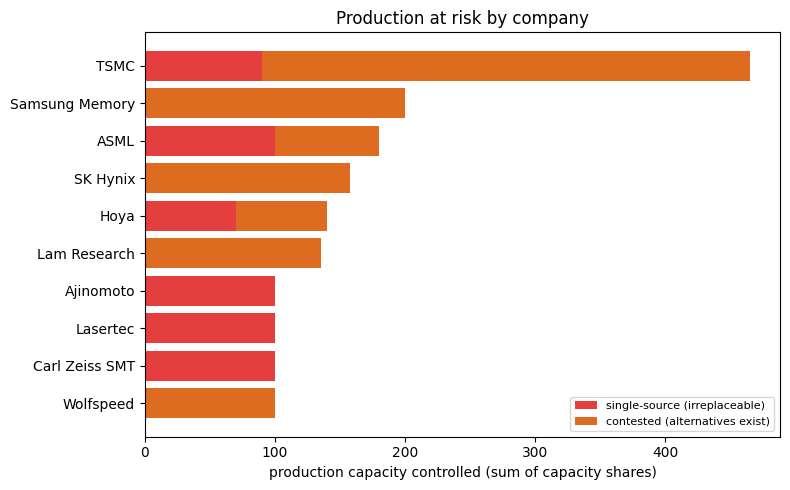

In [6]:
top = df_risk.sort_values('controlled', ascending=False).head(10)[::-1]
contested = (top['controlled'] - top['single_source']).clip(lower=0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['company'], top['single_source'], color='#e53e3e',
        label='single-source (irreplaceable)')
ax.barh(top['company'], contested, left=top['single_source'], color='#dd6b20',
        label='contested (alternatives exist)')
ax.set(xlabel='production capacity controlled (sum of capacity shares)',
       title='Production at risk by company')
ax.legend(fontsize=8)
fig.tight_layout()
out = analysis.FIGURES / '08_production_at_risk.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 4. Resilience, re-weighted by production capacity

Same attacks as notebook 07, but instead of *node count* in the giant component
we track the **share of production capacity** that remains connected.

In [7]:
U = analysis.company_supply_undirected(g)
N = U.number_of_nodes()

def attack(order):
    H = U.copy(); xs=[0.0]; nodes=[1.0]; wt=[1.0]
    for i, n in enumerate(order):
        if n in H: H.remove_node(n)
        xs.append((i+1)/N)
        if H.number_of_nodes():
            gcc = max(nx.connected_components(H), key=len)
            nodes.append(len(gcc)/N)
            wt.append(sum(w.get(x, 0) for x in gcc)/W)
        else:
            nodes.append(0); wt.append(0)
    return np.array(xs), np.array(nodes), np.array(wt)

order_w = sorted(U.nodes(), key=lambda n: w.get(n, 0), reverse=True)
x, n_topo, n_wt = attack(order_w)            # targeted by production weight

rng = np.random.default_rng(0); nodes=list(U.nodes()); runs=[]
for _ in range(30):
    rng.shuffle(nodes); _, _, rwt = attack(list(nodes)); runs.append(rwt)
rand_wt = np.mean(runs, axis=0)

hubs = ['TSMC','ASML','Shin-Etsu Chemical','Air Products','ARM']
H = U.copy(); H.remove_nodes_from(hubs)
gcc = max(nx.connected_components(H), key=len)
print(f'Remove 5 named hubs -> nodes in GCC: {len(gcc)/N:.0%}, '
      f'production capacity in GCC: {sum(w.get(x,0) for x in gcc)/W:.0%}')

Remove 5 named hubs -> nodes in GCC: 94%, production capacity in GCC: 74%


saved

 C:\Users\Max\Desktop\project\reports\figures\08_concentration.png


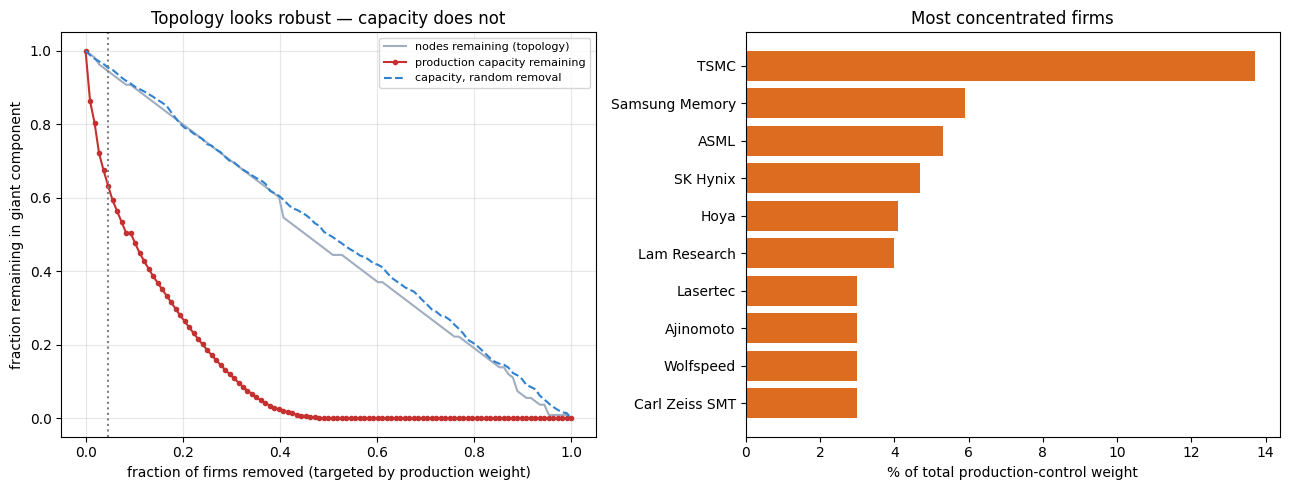

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(x, n_topo, '-', color='#a0aec0', label='nodes remaining (topology)')
ax.plot(x, n_wt, '-o', ms=3, color='#c53030', label='production capacity remaining')
ax.plot(x, rand_wt, '--', color='#3182ce', label='capacity, random removal')
ax.axvline(5/N, color='gray', ls=':')
ax.set(xlabel='fraction of firms removed (targeted by production weight)',
       ylabel='fraction remaining in giant component',
       title='Topology looks robust — capacity does not')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
top = df_w.head(10)[::-1]
ax2.barh(top['company'], top['% of total'], color='#dd6b20')
ax2.set(xlabel='% of total production-control weight',
        title='Most concentrated firms')
fig.tight_layout()
out = analysis.FIGURES / '08_concentration.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 5. Takeaways

- **The topological "robustness" is misleading.** Removing the five named hubs
  leaves ~94% of *firms* connected (notebook 07) but only ~**74% of production
  capacity** — and removing the top ~10 capacity holders erases ~**half** of all
  modelled output while the graph still looks largely connected.
- **The real single points of failure are products, not firms**: ~15 products
  have a single maker (EUV lithography → ASML, EUV optics → Zeiss, EUV mask
  blanks → Hoya, mask inspection → Lasertec, ABF film → Ajinomoto, 2nm → TSMC).
  These are exactly the chokepoints behind the 2020–2022 crisis.
- **Concentration is extreme even where competition nominally exists**: HBM,
  leading-edge logic (3/5nm), DUV all sit far above the HHI "highly concentrated"
  line.
- **Caveat:** capacity shares cover ~62% of MANUFACTURES edges and are public
  approximations; company→company volume shares (`volume_share_pct`) are public
  for only a few links (e.g. TSMC→Apple 25%, TSMC→Nvidia 10%), so the weighted
  view is strongest on the *production* layer.

**Conclusion:** weighting confirms the refined hypothesis from notebook 07 —
the network's fragility is real but **concentrated in specific high-share
chokepoints**, which a purely topological reading hides.